# Google Colab R

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


## Demonstration

This notebook uses the R kernel.


In [1]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] digest_0.6.39     IRdisplay_1.1     base64enc_0.1-6   fastmap_1.2.0    
 [5] glue_1.8.1        htmltools_0.5.9   repr_1.1.7        lifecycle_1.0.5  
 [9] cl

In [2]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
head(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


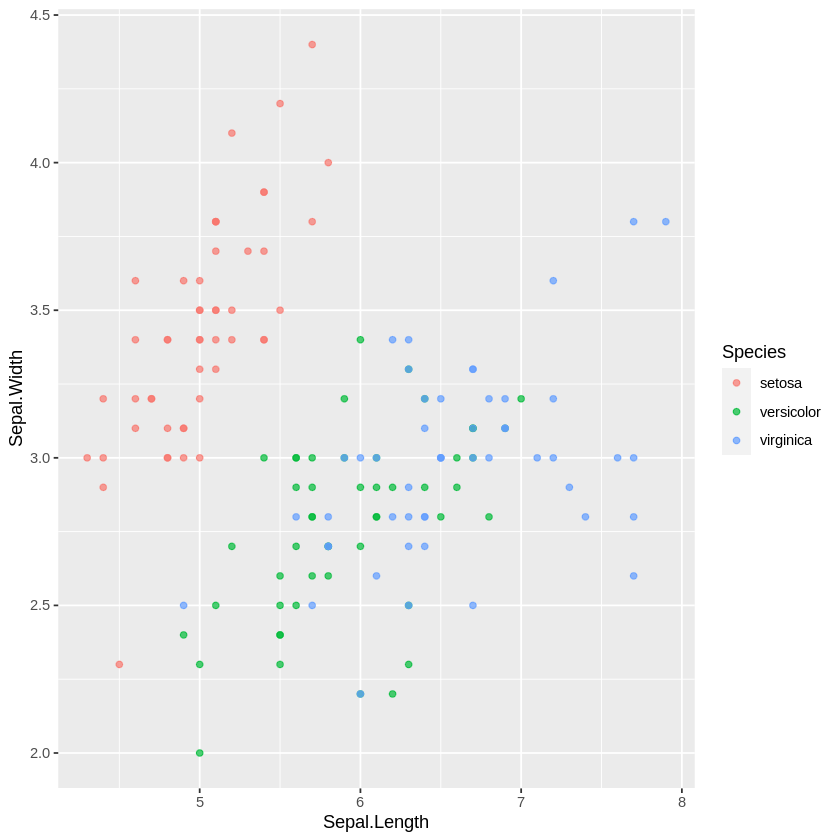

In [ ]:
iris %>%
ggplot(aes(Sepal.Length, Sepal.Width, color=Species))+
geom_point(alpha=0.7)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’, ‘dotty’


Installing package into ‘/usr/local/li

Weekly dataset dimensions: 574 6 
Column names: Date Macro_Health Social_Hype Price_Index Competitor_Release Ducati_Demand..1000.units. 


,Date,Macro_Health,Social_Hype,Price_Index,Competitor_Release,Ducati_Demand..1000.units.
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,04-01-2015,85.22495,0.00,20463.06,0,0.00
2,11-01-2015,118.96161,-4.85,19870.11,0,0.00
3,18-01-2015,87.56913,-6.35,20355.87,0,0.00
4,25-01-2015,79.73569,-3.46,20229.68,0,0.00
5,01-02-2015,95.97687,3.80,20066.60,0,30.83
6,08-02-2015,101.41774,2.42,20080.85,0,50.23


Total observations: 574 
Train ratio (randomised): 0.933 
Train size: 535 | Test size: 39 


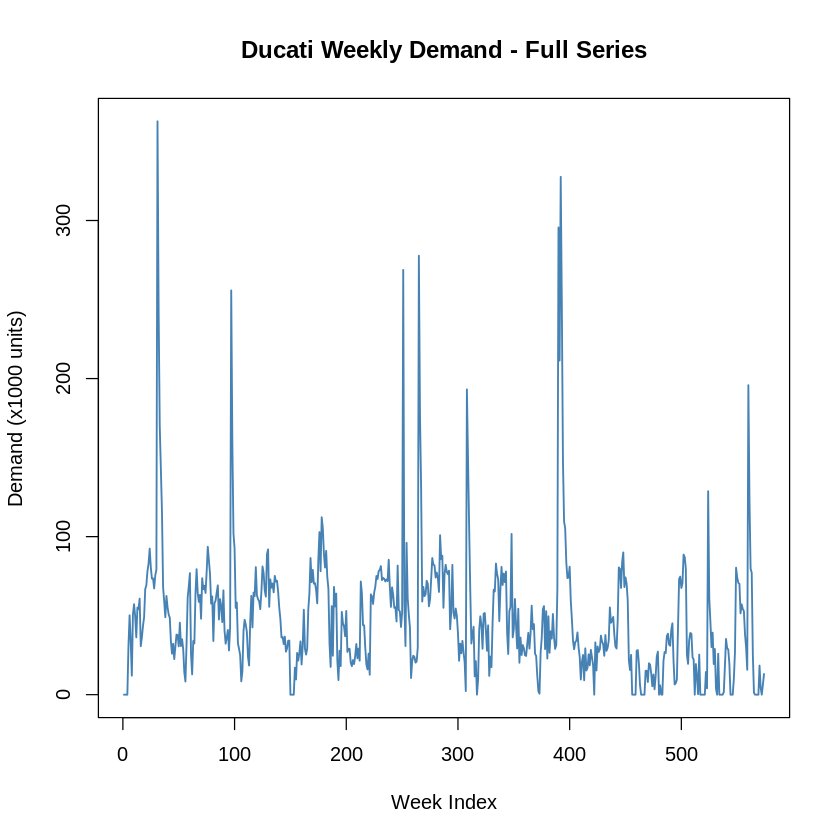

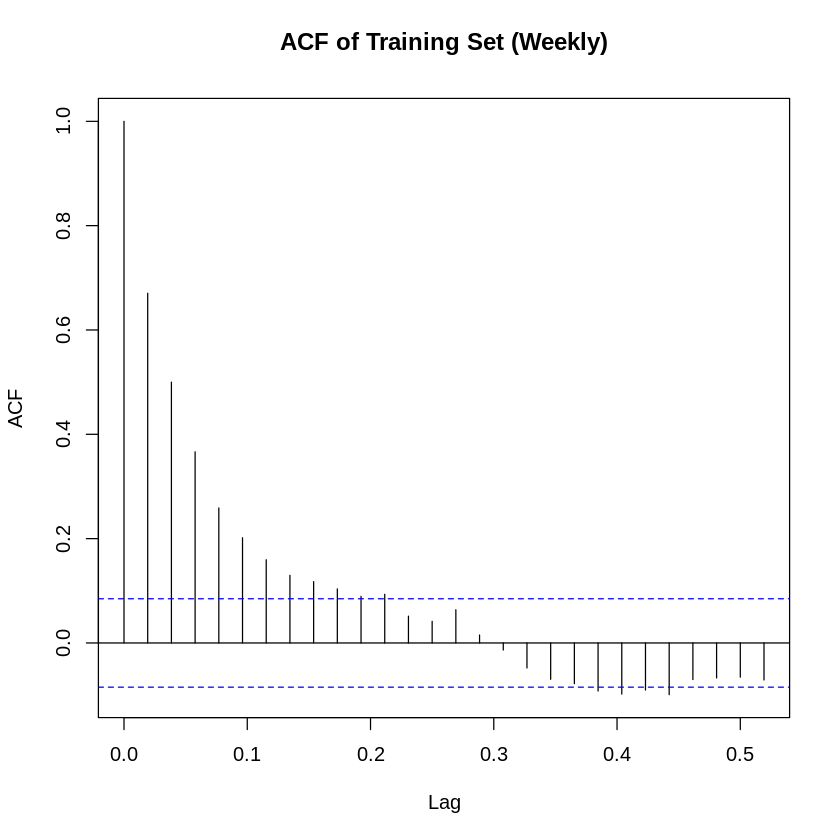

Warning message in adf.test(y_train_ts):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  y_train_ts
Dickey-Fuller = -6.0124, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


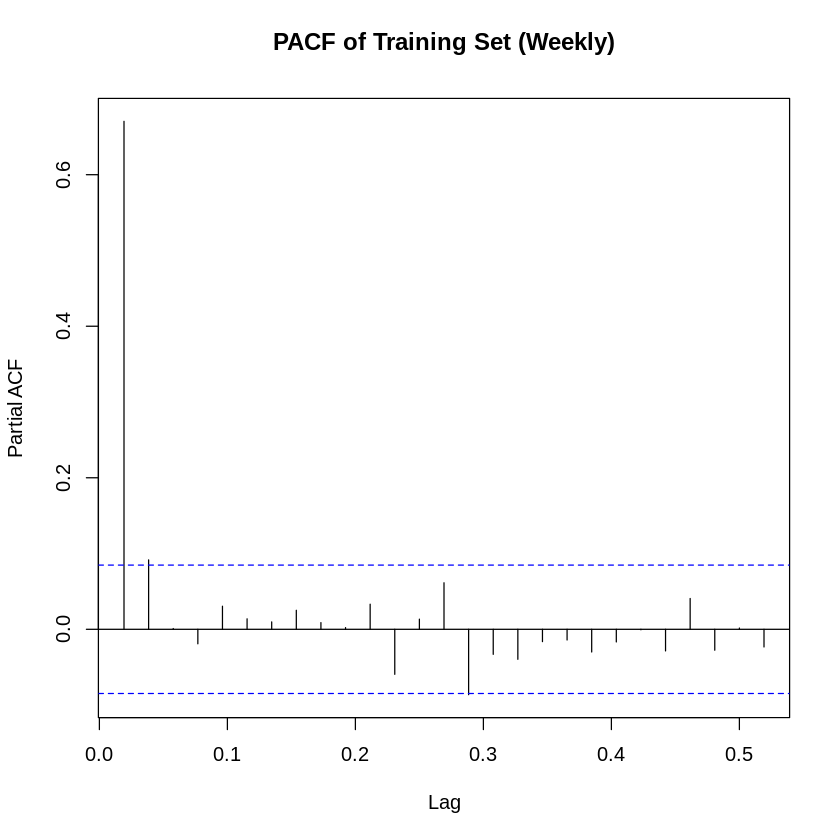

Residual SD (after decomposition): 35.63344 
Series SD (raw): 42.02447 

========== ARIMA ==========


In [ ]:
############################################################
# G01 - Advanced Forecasting Assignment
# Task 1: Weekly Dataset (ducatidemandweekly)
# Target: Ducati_Demand (x1000 units)
# Models: ARIMA (auto.arima + xreg), nnetar, LSTM (keras3)
############################################################

############################################################
# 0. Package Setup
############################################################

required_packages <- c("forecast", "ggplot2", "dplyr", "tidyr",
                       "tseries", "seastests", "keras3", "plotly", "openxlsx")

for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE, quietly = TRUE)) {
    install.packages(pkg)
    library(pkg, character.only = TRUE)
  }
}

############################################################
# 1. Evaluation Metric Functions
# (Consistent with class scripts - AFGW.R and ARIMA_PRACTICE.R)
############################################################

# RMSE: Root Mean Squared Error - magnitude of forecast error
rmse_fun <- function(actual, forecast) {
  actual <- as.numeric(actual); forecast <- as.numeric(forecast)
  sqrt(mean((actual - forecast)^2, na.rm = TRUE))
}

# CPA: Correlation of Predicted with Actual - directional accuracy
cpa_fun <- function(actual, forecast) {
  actual <- as.numeric(actual); forecast <- as.numeric(forecast)
  valid  <- complete.cases(actual, forecast)
  actual <- actual[valid]; forecast <- forecast[valid]
  if (length(actual) < 2 || sd(actual) == 0 || sd(forecast) == 0) return(0)
  cor(actual, forecast)
}

# SDR: Standard Deviation of Residuals - volatility of forecast errors
sdr_fun <- function(actual, forecast) {
  actual <- as.numeric(actual); forecast <- as.numeric(forecast)
  sd(actual - forecast, na.rm = TRUE)
}

############################################################
# 2. Load and Prepare Data
############################################################

dataset_w <- read.csv("/content/ducatidemandweekly.csv")
cat("Weekly dataset dimensions:", dim(dataset_w), "\n")
cat("Column names:", colnames(dataset_w), "\n")
head(dataset_w)

# Rename columns
colnames(dataset_w) <- c("Date", "Macro_Health", "Social_Hype",
                          "Price_Index", "Competitor_Release", "Ducati_Demand")

y_all    <- as.numeric(dataset_w$Ducati_Demand)
xreg_all <- as.matrix(dataset_w[, c("Macro_Health", "Social_Hype",
                                     "Price_Index", "Competitor_Release")])
n <- length(y_all)
cat("Total observations:", n, "\n")

############################################################
# 3. Randomised Train-Test Split (75%-95%)
############################################################

set.seed(42)
train_ratio <- runif(1, min = 0.75, max = 0.95)
train_size  <- floor(train_ratio * n)
test_size   <- n - train_size

cat("Train ratio (randomised):", round(train_ratio, 4), "\n")
cat("Train size:", train_size, "| Test size:", test_size, "\n")

freq_w <- 52  # Weekly seasonality

y_train_raw <- y_all[1:train_size]
y_test      <- y_all[(train_size + 1):n]
y_train_ts  <- ts(y_train_raw, frequency = freq_w)

xreg_train <- xreg_all[1:train_size, ]
xreg_test  <- xreg_all[(train_size + 1):n, ]

test_index <- (train_size + 1):n  # For x-axis in TS plots

############################################################
# 4. Time Series Diagnostics
############################################################

plot.ts(y_all, main = "Ducati Weekly Demand - Full Series",
        ylab = "Demand (x1000 units)", xlab = "Week Index", col = "steelblue", lwd = 1.5)

# ACF and PACF for ARIMA order identification
acf(y_train_ts,  main = "ACF of Training Set (Weekly)")
pacf(y_train_ts, main = "PACF of Training Set (Weekly)")

# ADF test for stationarity
adf.test(y_train_ts)

# Decompose to inspect trend and seasonality
if (length(y_train_ts) >= 2 * freq_w) {
  decomposed_w <- decompose(y_train_ts)
  plot(decomposed_w)
  cat("Residual SD (after decomposition):", sqrt(var(decomposed_w$random, na.rm = TRUE)), "\n")
  cat("Series SD (raw):", sqrt(var(decomposed_w$x, na.rm = TRUE)), "\n")
}

############################################################
# 5. SECTION 1: ARIMA with External Regressors
############################################################

cat("\n========== ARIMA ==========\n")

# auto.arima searches all p,d,q,P,D,Q configurations and selects best by AICc.
# stepwise=FALSE and approximation=FALSE ensure exhaustive search (slower but thorough).
# xreg supplies external regressors to the model.
m_arima <- auto.arima(
  y_train_ts,
  xreg          = xreg_train,
  stepwise      = TRUE,
  approximation = TRUE,
  seasonal      = TRUE,
  trace         = TRUE
)

cat("\nChosen ARIMA Configuration:\n")
print(m_arima)
cat("ARIMA Order (p,d,q)   :", arimaorder(m_arima)[1:3], "\n")
cat("Seasonal Order (P,D,Q):", arimaorder(m_arima)[4:6], "\n")

# Forecast over test horizon. External regressor data for test period
# is assumed available at end of training horizon (per assignment instruction).
fc_arima <- forecast(m_arima, h = test_size, xreg = xreg_test)

# --- Plots: professor's style (plot.ts + lines) and autoplot ---
autoplot(fc_arima) +
  labs(title = "ARIMA: Multi-Step Forecast (Train + Test Horizon)",
       x = "Time", y = "Ducati Demand (x1000 units)")

# Actual vs Forecast on test period only (base R style as in class)
plot.ts(y_test,
        main = "ARIMA: Actual vs Forecast on Test Set",
        ylab = "Ducati Demand (x1000 units)", xlab = "Test Week Index",
        col = "steelblue", lwd = 2)
lines(as.numeric(fc_arima$mean), col = "tomato", lwd = 2)
legend("topright", legend = c("Actual", "ARIMA Forecast"),
       col = c("steelblue", "tomato"), lwd = 2)

# Compute test metrics
arima_rmse <- rmse_fun(y_test, fc_arima$mean)
arima_cpa  <- cpa_fun(y_test,  fc_arima$mean)
arima_sdr  <- sdr_fun(y_test,  fc_arima$mean)

cat("\nARIMA Test Performance:\n")
cat("  RMSE:", round(arima_rmse, 4), "\n")
cat("  CPA: ", round(arima_cpa,  4), "\n")
cat("  SDR: ", round(arima_sdr,  4), "\n")

fc_arima_vec <- as.numeric(fc_arima$mean)

# ---- CHECKPOINT SAVE (ARIMA done) ----
save.image("D:/MBA_SPJIMR/04_Term-4/AF/G01_weekly.RData")
cat(">> Checkpoint saved after ARIMA.\n")

############################################################
# 6. SECTION 2: nnetar Hyperparameter Tuning
############################################################

cat("\n========== NNETAR HYPERPARAMETER TUNING ==========\n")

# Hyperparameter Descriptions:
# p       : Number of non-seasonal AR lags used as inputs to the network.
#           Controls how many past y values the ANN sees at each step.
# P       : Number of seasonal AR lags (each lag is 'frequency' steps apart).
#           Helps capture periodic patterns (e.g., 52-week seasonality).
# size    : Number of hidden nodes in the single hidden layer.
#           Larger = more capacity, but higher risk of overfitting.
# repeats : Number of independently initialised networks whose forecasts are averaged.
#           More repeats = more stable forecast at cost of compute time.

p_grid       <- c(1, 2, 3, 5, 8, 10, 13, 15, 20, 25)
P_grid       <- c(0, 1, 2, 3, 4, 5, 6, 7, 8, 10)
size_grid    <- c(2, 4, 6, 8, 10, 12, 14, 15)
repeats_grid <- c(5, 10, 15, 20)

# Build full 10^4 grid, randomly sample 500 unique configurations
set.seed(101)
full_grid_nn  <- expand.grid(p = p_grid, P = P_grid,
                              size = size_grid, repeats = repeats_grid)
hp_grid_nn    <- full_grid_nn[sample(nrow(full_grid_nn), 250, replace = FALSE), ]
cat("nnetar configurations to run:", nrow(hp_grid_nn), "\n")

nn_results <- data.frame(p = integer(), P = integer(),
                          size = integer(), repeats = integer(),
                          RMSE = numeric(), CPA = numeric(), SDR = numeric())

for (i in seq_len(nrow(hp_grid_nn))) {
  hp <- hp_grid_nn[i, ]
  res <- tryCatch({
    m_nn  <- nnetar(y_train_ts, p = hp$p, P = hp$P,
                    size = hp$size, repeats = hp$repeats, xreg = xreg_train)
    fc_nn <- forecast(m_nn, h = test_size, xreg = xreg_test)
    fv    <- as.numeric(fc_nn$mean)
    data.frame(p = hp$p, P = hp$P, size = hp$size, repeats = hp$repeats,
               RMSE = rmse_fun(y_test, fv),
               CPA  = cpa_fun(y_test,  fv),
               SDR  = sdr_fun(y_test,  fv))
  }, error = function(e) {
    data.frame(p = hp$p, P = hp$P, size = hp$size, repeats = hp$repeats,
               RMSE = NA, CPA = NA, SDR = NA)
  })
  nn_results <- rbind(nn_results, res)
  if (i %% 50 == 0) cat("  nnetar:", i, "/", nrow(hp_grid_nn), "done\n")
}

# Clean and sort
nn_results <- nn_results[!is.na(nn_results$RMSE), ]
nn_results <- nn_results[order(nn_results$RMSE), ]
cat("nnetar valid runs:", nrow(nn_results), "\n")

# Report subsets
nn_top10    <- head(nn_results, 10)
nn_bottom10 <- tail(nn_results, 10)
cat("\nnnetar Report Table (Top 10 + Bottom 10 by RMSE):\n")
print(rbind(nn_top10, nn_bottom10))

# ---- Save nnetar results to Excel immediately ----
wb_w <- createWorkbook()
addWorksheet(wb_w, "Task1_nnetar")
writeData(wb_w, "Task1_nnetar", nn_results)
saveWorkbook(wb_w, "D:/MBA_SPJIMR/04_Term-4/AF/G01_hpamresults.xlsx", overwrite = TRUE)
cat(">> nnetar results saved to Excel.\n")

# ---- CHECKPOINT SAVE (nnetar done) ----
save.image("D:/MBA_SPJIMR/04_Term-4/AF/G01_weekly.RData")
cat(">> Checkpoint saved after nnetar.\n")

# --- Refit best nnetar model ---
best_nn <- nn_top10[1, ]
cat("\nBest nnetar: p=", best_nn$p, "P=", best_nn$P,
    "size=", best_nn$size, "repeats=", best_nn$repeats, "\n")

m_nn_best      <- nnetar(y_train_ts, p = best_nn$p, P = best_nn$P,
                          size = best_nn$size, repeats = best_nn$repeats, xreg = xreg_train)
fc_nn_best     <- forecast(m_nn_best, h = test_size, xreg = xreg_test)
fc_nn_best_vec <- as.numeric(fc_nn_best$mean)

nn_best_rmse <- rmse_fun(y_test, fc_nn_best_vec)
nn_best_cpa  <- cpa_fun(y_test,  fc_nn_best_vec)
nn_best_sdr  <- sdr_fun(y_test,  fc_nn_best_vec)

cat("Best nnetar Test Performance:\n")
cat("  RMSE:", round(nn_best_rmse, 4), "\n")
cat("  CPA: ", round(nn_best_cpa,  4), "\n")
cat("  SDR: ", round(nn_best_sdr,  4), "\n")

# --- Plots for best nnetar ---
autoplot(fc_nn_best) +
  labs(title = "nnetar (Best): Multi-Step Forecast",
       x = "Time", y = "Ducati Demand (x1000 units)")

plot.ts(y_test,
        main = "nnetar (Best): Actual vs Forecast on Test Set",
        ylab = "Ducati Demand (x1000 units)", xlab = "Test Week Index",
        col = "steelblue", lwd = 2)
lines(fc_nn_best_vec, col = "tomato", lwd = 2)
legend("topright", legend = c("Actual", "nnetar Forecast"),
       col = c("steelblue", "tomato"), lwd = 2)

# --- 3-D Surface Plot: RMSE vs p and size (most influential hyperparameters) ---
nn_3d <- plot_ly(
  data = nn_results, x = ~p, y = ~size, z = ~RMSE,
  type = "scatter3d", mode = "markers",
  marker = list(size = 3, color = ~RMSE, colorscale = "Viridis", showscale = TRUE)
) %>% layout(
  title = "nnetar: RMSE vs p (AR Lags) vs size (Hidden Nodes)",
  scene = list(xaxis = list(title = "p"), yaxis = list(title = "size"),
               zaxis = list(title = "RMSE"))
)
print(nn_3d)

# --- TS plots: Top 5 and Worst 5 nnetar ---
top5_nn  <- nn_results[1:5, ]
bot5_nn  <- tail(nn_results, 5)
nn_plot_set <- rbind(top5_nn, bot5_nn)

for (i in seq_len(nrow(nn_plot_set))) {
  hp_i <- nn_plot_set[i, ]
  rl   <- if (i <= 5) paste0("Top-", i) else paste0("Worst-", i - 5)

  m_tmp <- tryCatch(
    nnetar(y_train_ts, p = hp_i$p, P = hp_i$P,
           size = hp_i$size, repeats = hp_i$repeats, xreg = xreg_train),
    error = function(e) NULL)
  if (is.null(m_tmp)) next
  fc_tmp <- as.numeric(forecast(m_tmp, h = test_size, xreg = xreg_test)$mean)

  # Base R plot (professor's style)
  yrange <- range(c(as.numeric(y_test), fc_tmp), na.rm = TRUE)
  plot.ts(y_test, ylim = yrange,
          main = paste0("nnetar [", rl, "] p=", hp_i$p, " P=", hp_i$P,
                        " size=", hp_i$size, " rep=", hp_i$repeats,
                        " | RMSE=", round(hp_i$RMSE, 3)),
          ylab = "Ducati Demand (x1000 units)", xlab = "Test Week Index",
          col = "steelblue", lwd = 2)
  lines(fc_tmp, col = "tomato", lwd = 2)
  legend("topright", legend = c("Actual", "Forecast"),
         col = c("steelblue", "tomato"), lwd = 2)
}

############################################################
# 7. SECTION 3: LSTM Hyperparameter Tuning (keras3)
############################################################

cat("\n========== LSTM HYPERPARAMETER TUNING ==========\n")

# Hyperparameter Descriptions:
# lstm_lags           : Length of input sequence (look-back window) fed to the LSTM.
#                       Determines how many past time steps the model processes.
# lstm_units_1        : LSTM memory units in Layer 1. More units = richer pattern capture.
# lstm_units_2        : LSTM memory units in Layer 2. Adds depth for hierarchical features.
# lstm_dropout_rate   : Proportion of neurons randomly disabled each training step.
#                       Acts as regularisation to prevent overfitting.
# lstm_epochs         : Full passes over training data. Too few = underfit; too many = overfit.
# lstm_batch_size     : Samples per gradient update. Smaller = noisier updates, better generalisation.
# lstm_validation_split : Held-out fraction of training data for monitoring validation loss.
# lstm_learning_rate  : Adam optimiser step size. Too high diverges; too low is slow.

# Multivariate LSTM array builder [samples, lags, features]
make_lstm_array_mv <- function(mat, lags) {
  n_rows <- nrow(mat); n_feat <- ncol(mat)
  x_arr  <- array(0, dim = c(n_rows - lags, lags, n_feat))
  for (i in 1:(n_rows - lags)) x_arr[i, , ] <- mat[i:(i + lags - 1), ]
  list(x = x_arr, y = mat[(lags + 1):n_rows, 1])
}

# Scale using training statistics only (avoids data leakage)
y_mean  <- mean(y_train_raw); y_sd <- sd(y_train_raw)
x_means <- colMeans(xreg_train); x_sds <- apply(xreg_train, 2, sd)

y_train_sc    <- as.numeric(scale(y_train_raw, center = y_mean, scale = y_sd))
xreg_train_sc <- sweep(sweep(xreg_train, 2, x_means, "-"), 2, x_sds, "/")
xreg_test_sc  <- sweep(sweep(xreg_test,  2, x_means, "-"), 2, x_sds, "/")

n_features <- ncol(xreg_train) + 1  # y column + 4 xreg columns

# Hyperparameter search grids (10 values each -> diverse coverage)
lstm_lags_grid     <- c(4, 8, 12, 16, 20, 26, 30, 40, 52, 60)
lstm_units1_grid   <- c(4, 8, 12, 16, 20, 24, 28, 32)
lstm_units2_grid   <- c(2, 4, 6, 8, 10, 12, 14, 16)
lstm_dropout_grid  <- c(0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50)
lstm_epochs_grid   <- c(20, 30, 40, 50, 60, 70, 80, 100)
lstm_batch_grid    <- c(4, 8, 12, 16, 24, 32, 48, 64, 96, 128)
lstm_valsplit_grid <- c(0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30, 0.35)
lstm_lr_grid       <- c(0.0001, 0.0003, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.02)

set.seed(202)
lstm_hp_grid <- data.frame(
  lstm_lags             = sample(lstm_lags_grid,     250, replace = TRUE),
  lstm_units_1          = sample(lstm_units1_grid,   250, replace = TRUE),
  lstm_units_2          = sample(lstm_units2_grid,   250, replace = TRUE),
  lstm_dropout_rate     = sample(lstm_dropout_grid,  250, replace = TRUE),
  lstm_epochs           = sample(lstm_epochs_grid,   250, replace = TRUE),
  lstm_batch_size       = sample(lstm_batch_grid,    250, replace = TRUE),
  lstm_validation_split = sample(lstm_valsplit_grid, 250, replace = TRUE),
  lstm_learning_rate    = sample(lstm_lr_grid,       250, replace = TRUE)
)
lstm_hp_grid <- unique(lstm_hp_grid)
cat("Unique LSTM configurations:", nrow(lstm_hp_grid), "\n")

lstm_results <- data.frame(
  lstm_lags = integer(), lstm_units_1 = integer(), lstm_units_2 = integer(),
  lstm_dropout_rate = numeric(), lstm_epochs = integer(),
  lstm_batch_size = integer(), lstm_validation_split = numeric(),
  lstm_learning_rate = numeric(),
  train_loss = numeric(), val_loss = numeric(),
  RMSE = numeric(), CPA = numeric(), SDR = numeric()
)

for (i in seq_len(nrow(lstm_hp_grid))) {
  hp <- lstm_hp_grid[i, ]

  res_lstm <- tryCatch({
    tm_sc <- cbind(y_train_sc, xreg_train_sc)
    ld    <- make_lstm_array_mv(tm_sc, hp$lstm_lags)

    mi <- keras3::keras_model_sequential() |>
      keras3::layer_lstm(units = hp$lstm_units_1, return_sequences = TRUE,
                         input_shape = c(hp$lstm_lags, n_features)) |>
      keras3::layer_dropout(rate = hp$lstm_dropout_rate) |>
      keras3::layer_lstm(units = hp$lstm_units_2, return_sequences = FALSE) |>
      keras3::layer_dropout(rate = hp$lstm_dropout_rate) |>
      keras3::layer_dense(units = 1)

    mi |> keras3::compile(
      optimizer = keras3::optimizer_adam(learning_rate = hp$lstm_learning_rate),
      loss = "mse")

    hi <- mi |> keras3::fit(
      ld$x, ld$y,
      epochs = hp$lstm_epochs, batch_size = hp$lstm_batch_size,
      validation_split = hp$lstm_validation_split,
      shuffle = FALSE, verbose = 0)

    tl <- tail(hi$metrics$loss, 1)
    vl <- tail(hi$metrics$val_loss, 1)

    # Iterative recursive forecast over test horizon
    yh    <- y_train_sc
    xa    <- rbind(xreg_train_sc, xreg_test_sc)
    fc_sc <- numeric(test_size)

    for (j in 1:test_size) {
      ci <- train_size + (j - 1); ws <- ci - hp$lstm_lags + 1
      iw <- cbind(yh[ws:ci], xa[ws:ci, , drop = FALSE])
      fc_sc[j] <- as.numeric(predict(mi, array(iw, dim = c(1, hp$lstm_lags, n_features)), verbose = 0))
      yh <- c(yh, fc_sc[j])
    }
    fc_i <- fc_sc * y_sd + y_mean

    data.frame(lstm_lags = hp$lstm_lags, lstm_units_1 = hp$lstm_units_1,
               lstm_units_2 = hp$lstm_units_2, lstm_dropout_rate = hp$lstm_dropout_rate,
               lstm_epochs = hp$lstm_epochs, lstm_batch_size = hp$lstm_batch_size,
               lstm_validation_split = hp$lstm_validation_split,
               lstm_learning_rate = hp$lstm_learning_rate,
               train_loss = tl, val_loss = vl,
               RMSE = rmse_fun(y_test, fc_i),
               CPA  = cpa_fun(y_test,  fc_i),
               SDR  = sdr_fun(y_test,  fc_i))
  }, error = function(e) {
    data.frame(lstm_lags = hp$lstm_lags, lstm_units_1 = hp$lstm_units_1,
               lstm_units_2 = hp$lstm_units_2, lstm_dropout_rate = hp$lstm_dropout_rate,
               lstm_epochs = hp$lstm_epochs, lstm_batch_size = hp$lstm_batch_size,
               lstm_validation_split = hp$lstm_validation_split,
               lstm_learning_rate = hp$lstm_learning_rate,
               train_loss = NA, val_loss = NA, RMSE = NA, CPA = NA, SDR = NA)
  })

  lstm_results <- rbind(lstm_results, res_lstm)

  # Save intermediate results every 50 runs (protects against crashes)
  if (i %% 50 == 0) {
    cat("  LSTM:", i, "/", nrow(lstm_hp_grid), "done\n")
    save.image("D:/MBA_SPJIMR/04_Term-4/AF/G01_weekly.RData")
    # Also update Excel with progress so far
    lstm_valid_so_far <- lstm_results[!is.na(lstm_results$RMSE), ]
    if (nrow(lstm_valid_so_far) > 0) {
      wb_tmp <- loadWorkbook("D:/MBA_SPJIMR/04_Term-4/AF/G01_hpamresults.xlsx")
      if ("Task1_LSTM" %in% names(wb_tmp)) removeWorksheet(wb_tmp, "Task1_LSTM")
      addWorksheet(wb_tmp, "Task1_LSTM")
      writeData(wb_tmp, "Task1_LSTM", lstm_valid_so_far[order(lstm_valid_so_far$RMSE), ])
      saveWorkbook(wb_tmp, "D:/MBA_SPJIMR/04_Term-4/AF/G01_hpamresults.xlsx", overwrite = TRUE)
    }
    # Clear Keras session to prevent memory leak crashes over hundreds of models
  keras3::k_clear_session()
  gc()
}
}

# Final clean and sort
lstm_results <- lstm_results[!is.na(lstm_results$RMSE), ]
lstm_results <- lstm_results[order(lstm_results$RMSE), ]
cat("LSTM valid runs:", nrow(lstm_results), "\n")

lstm_top10    <- head(lstm_results, 10)
lstm_bottom10 <- tail(lstm_results, 10)
cat("\nLSTM Report Table (Top 10 + Bottom 10 by RMSE):\n")
print(rbind(lstm_top10, lstm_bottom10))

# ---- Save final LSTM results to Excel ----
wb_final <- loadWorkbook("D:/MBA_SPJIMR/04_Term-4/AF/G01_hpamresults.xlsx")
if ("Task1_LSTM" %in% names(wb_final)) removeWorksheet(wb_final, "Task1_LSTM")
addWorksheet(wb_final, "Task1_LSTM")
writeData(wb_final, "Task1_LSTM", lstm_results)
saveWorkbook(wb_final, "D:/MBA_SPJIMR/04_Term-4/AF/G01_hpamresults.xlsx", overwrite = TRUE)
cat(">> LSTM results saved to Excel.\n")

# ---- CHECKPOINT SAVE (LSTM done) ----
save.image("D:/MBA_SPJIMR/04_Term-4/AF/G01_weekly.RData")
cat(">> Checkpoint saved after LSTM.\n")

# --- Refit best LSTM ---
best_lstm <- lstm_top10[1, ]
cat("\nBest LSTM: lags=", best_lstm$lstm_lags, "units1=", best_lstm$lstm_units_1,
    "units2=", best_lstm$lstm_units_2, "\n")

train_mat_best <- cbind(y_train_sc, xreg_train_sc)
ld_best        <- make_lstm_array_mv(train_mat_best, best_lstm$lstm_lags)

model_lstm_best <- keras3::keras_model_sequential() |>
  keras3::layer_lstm(units = best_lstm$lstm_units_1, return_sequences = TRUE,
                     input_shape = c(best_lstm$lstm_lags, n_features)) |>
  keras3::layer_dropout(rate = best_lstm$lstm_dropout_rate) |>
  keras3::layer_lstm(units = best_lstm$lstm_units_2, return_sequences = FALSE) |>
  keras3::layer_dropout(rate = best_lstm$lstm_dropout_rate) |>
  keras3::layer_dense(units = 1)

model_lstm_best |> keras3::compile(
  optimizer = keras3::optimizer_adam(learning_rate = best_lstm$lstm_learning_rate),
  loss = "mse")

history_lstm_best <- model_lstm_best |> keras3::fit(
  ld_best$x, ld_best$y,
  epochs = best_lstm$lstm_epochs, batch_size = best_lstm$lstm_batch_size,
  validation_split = best_lstm$lstm_validation_split,
  shuffle = FALSE, verbose = 1)

# Plot training history
plot(history_lstm_best$metrics$loss, type = "l", col = "steelblue",
     main = "LSTM Best Model: Training vs Validation Loss",
     xlab = "Epoch", ylab = "MSE Loss", lwd = 2)
lines(history_lstm_best$metrics$val_loss, col = "tomato", lwd = 2)
legend("topright", legend = c("Train Loss", "Val Loss"),
       col = c("steelblue", "tomato"), lwd = 2)

# Iterative forecast with best LSTM
yh_b  <- y_train_sc
xa_b  <- rbind(xreg_train_sc, xreg_test_sc)
fc_b_sc <- numeric(test_size)
for (j in 1:test_size) {
  ci <- train_size + (j - 1); ws <- ci - best_lstm$lstm_lags + 1
  iw <- cbind(yh_b[ws:ci], xa_b[ws:ci, , drop = FALSE])
  fc_b_sc[j] <- as.numeric(predict(model_lstm_best,
                                    array(iw, dim = c(1, best_lstm$lstm_lags, n_features)), verbose = 0))
  yh_b <- c(yh_b, fc_b_sc[j])
}
fc_lstm_best_vec <- fc_b_sc * y_sd + y_mean

lstm_best_rmse <- rmse_fun(y_test, fc_lstm_best_vec)
lstm_best_cpa  <- cpa_fun(y_test,  fc_lstm_best_vec)
lstm_best_sdr  <- sdr_fun(y_test,  fc_lstm_best_vec)

cat("Best LSTM Test Performance:\n")
cat("  RMSE:", round(lstm_best_rmse, 4), "\n")
cat("  CPA: ", round(lstm_best_cpa,  4), "\n")
cat("  SDR: ", round(lstm_best_sdr,  4), "\n")

# --- Plots for best LSTM ---
plot.ts(y_test,
        main = "LSTM (Best): Actual vs Forecast on Test Set",
        ylab = "Ducati Demand (x1000 units)", xlab = "Test Week Index",
        col = "steelblue", lwd = 2)
lines(fc_lstm_best_vec, col = "darkorange", lwd = 2)
legend("topright", legend = c("Actual", "LSTM Forecast"),
       col = c("steelblue", "darkorange"), lwd = 2)

# --- 3-D Surface Plot: RMSE vs lstm_lags and lstm_units_1 ---
lstm_3d <- plot_ly(
  data = lstm_results, x = ~lstm_lags, y = ~lstm_units_1, z = ~RMSE,
  type = "scatter3d", mode = "markers",
  marker = list(size = 3, color = ~RMSE, colorscale = "Plasma", showscale = TRUE)
) %>% layout(
  title = "LSTM: RMSE vs lstm_lags vs lstm_units_1",
  scene = list(xaxis = list(title = "lstm_lags"),
               yaxis = list(title = "lstm_units_1"),
               zaxis = list(title = "RMSE"))
)
print(lstm_3d)

# --- TS plots: Top 5 and Worst 5 LSTM ---
top5_lstm  <- lstm_results[1:5, ]
bot5_lstm  <- tail(lstm_results, 5)
lstm_plot_set <- rbind(top5_lstm, bot5_lstm)

for (i in seq_len(nrow(lstm_plot_set))) {
  hp_i <- lstm_plot_set[i, ]
  rl   <- if (i <= 5) paste0("Top-", i) else paste0("Worst-", i - 5)

  fc_tmp <- tryCatch({
    tm <- cbind(y_train_sc, xreg_train_sc)
    ld <- make_lstm_array_mv(tm, hp_i$lstm_lags)
    mi <- keras3::keras_model_sequential() |>
      keras3::layer_lstm(units = hp_i$lstm_units_1, return_sequences = TRUE,
                         input_shape = c(hp_i$lstm_lags, n_features)) |>
      keras3::layer_dropout(rate = hp_i$lstm_dropout_rate) |>
      keras3::layer_lstm(units = hp_i$lstm_units_2, return_sequences = FALSE) |>
      keras3::layer_dropout(rate = hp_i$lstm_dropout_rate) |>
      keras3::layer_dense(units = 1)
    mi |> keras3::compile(optimizer = keras3::optimizer_adam(learning_rate = hp_i$lstm_learning_rate), loss = "mse")
    mi |> keras3::fit(ld$x, ld$y, epochs = hp_i$lstm_epochs, batch_size = hp_i$lstm_batch_size,
                      validation_split = hp_i$lstm_validation_split, shuffle = FALSE, verbose = 0)
    yh <- y_train_sc; xa <- rbind(xreg_train_sc, xreg_test_sc); fsc <- numeric(test_size)
    for (j in 1:test_size) {
      ci <- train_size + (j-1); ws <- ci - hp_i$lstm_lags + 1
      iw <- cbind(yh[ws:ci], xa[ws:ci, , drop = FALSE])
      fsc[j] <- as.numeric(predict(mi, array(iw, dim = c(1, hp_i$lstm_lags, n_features)), verbose = 0))
      yh <- c(yh, fsc[j])
    }
    fsc * y_sd + y_mean
  }, error = function(e) rep(NA, test_size))

  if (all(is.na(fc_tmp))) next

  yrange <- range(c(as.numeric(y_test), fc_tmp), na.rm = TRUE)
  plot.ts(y_test, ylim = yrange,
          main = paste0("LSTM [", rl, "] lags=", hp_i$lstm_lags,
                        " u1=", hp_i$lstm_units_1, " u2=", hp_i$lstm_units_2,
                        " | RMSE=", round(hp_i$RMSE, 3)),
          ylab = "Ducati Demand (x1000 units)", xlab = "Test Week Index",
          col = "steelblue", lwd = 2)
  lines(fc_tmp, col = "darkorange", lwd = 2)
  legend("topright", legend = c("Actual", "LSTM Forecast"),
         col = c("steelblue", "darkorange"), lwd = 2)
}

############################################################
# 8. Model Comparison Table (Task 1)
############################################################

cat("\n========== MODEL COMPARISON - TASK 1 ==========\n")

comparison_table_w <- data.frame(
  Model_Family = c("ARIMA (auto.arima + xreg)",
                   "ANN - nnetar",
                   "ANN - LSTM (keras3)"),
  RMSE = round(c(arima_rmse, nn_best_rmse, lstm_best_rmse), 4),
  CPA  = round(c(arima_cpa,  nn_best_cpa,  lstm_best_cpa),  4),
  SDR  = round(c(arima_sdr,  nn_best_sdr,  lstm_best_sdr),  4)
)
print(comparison_table_w)

############################################################
# 9. Final Environment Save
############################################################

save.image("D:/MBA_SPJIMR/04_Term-4/AF/G01_weekly.RData")
cat(">> G01_weekly.RData saved.\n")
cat(">> G01_hpamresults.xlsx updated.\n")
cat("\n========== TASK 1 COMPLETE ==========\n")

